In [11]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import time

ARXIV_URL = "http://export.arxiv.org/api/query"
NS = "{http://www.w3.org/2005/Atom}"

CATEGORIES = {
    "Space Physics":    "cat:physics.space-ph",
    "Solar Stellar":    "cat:astro-ph.SR",
    "Earth Planetary":  "cat:astro-ph.EP",
    "Geophysics":       "cat:physics.geo-ph",
}

def fetch_arxiv(query, label, max_results=300):
    records = []
    batch_size = 100
    for start in range(0, max_results, batch_size):
        params = {
            "search_query": query,
            "start":        start,
            "max_results":  batch_size,
            "sortBy":       "submittedDate",
            "sortOrder":    "descending",
        }
        r = requests.get(ARXIV_URL, params=params, timeout=30)
        root = ET.fromstring(r.text)
        entries = root.findall(f"{NS}entry")
        if not entries:
            break
        for entry in entries:
            title   = entry.find(f"{NS}title")
            summary = entry.find(f"{NS}summary")
            if title is not None and summary is not None:
                text = title.text.strip() + " " + summary.text.strip()
                records.append({"text": text, "label": label})
        print(f"  {label}: {start + len(entries)} so far")
        time.sleep(3)
    return records

all_records = []
for label, query in CATEGORIES.items():
    print(f"\nFetching: {label}")
    recs = fetch_arxiv(query, label, max_results=300)
    all_records.extend(recs)

df = pd.DataFrame(all_records).drop_duplicates(subset=["text"])
print(f"\nTotal: {len(df)}")
print(df["label"].value_counts())
df.to_csv("solar_events.csv", index=False)
print("Saved: solar_events.csv")


Fetching: Space Physics
  Space Physics: 100 so far
  Space Physics: 200 so far
  Space Physics: 300 so far

Fetching: Solar Stellar
  Solar Stellar: 100 so far
  Solar Stellar: 200 so far
  Solar Stellar: 300 so far

Fetching: Earth Planetary
  Earth Planetary: 100 so far
  Earth Planetary: 200 so far
  Earth Planetary: 300 so far

Fetching: Geophysics
  Geophysics: 100 so far
  Geophysics: 200 so far
  Geophysics: 300 so far

Total: 1091
label
Space Physics      300
Solar Stellar      286
Geophysics         285
Earth Planetary    220
Name: count, dtype: int64
Saved: solar_events.csv


In [12]:
# Check a sample from each class
for label in df["label"].unique():
    sample = df[df["label"] == label].iloc[0]["text"]
    print(f"\n{'='*50}")
    print(f"LABEL: {label}")
    print(f"TEXT: {sample[:300]}")


LABEL: Space Physics
TEXT: Normal-Field Evolution and the Breakdown of Classical Tearing in Current Sheets Classical resistive tearing theory assumes a prescribed current-sheet equilibrium, but a finite normal magnetic field can evolve the background on the tearing timescale. For a transversely pressure-balanced Harris profil

LABEL: Solar Stellar
TEXT: A New Framework for Modeling Solar Flares from MHD to Kinetic Processes Physical processes in solar flares span many orders of magnitude in spatiotemporal scales, so a single unified model accounting for all relevant processes remains computationally intractable. Instead, specialized codes have been

LABEL: Earth Planetary
TEXT: Interpreting effective homogeneous rheologies through a local differential map with application to the Moon Layered viscoelastic interiors control the frequency dependence of planetary tidal dissipation, but repeated layered Love-number calculations are expensive in long-term orbital and spin integr

LABEL: Geo

In [13]:
from google.colab import files
files.download("solar_events.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

============================ TRAINING =================================

In [11]:
# Cell 1 — Install and imports
!pip install transformers datasets scikit-learn -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu130
GPU available: True


In [12]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("solar_events.csv")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df["label"].value_counts())
print(f"\nSample text length: {df['text'].str.len().describe()}")

Saving solar_events.csv to solar_events.csv
Shape: (1091, 2)

Class distribution:
label
Space Physics      300
Solar Stellar      286
Geophysics         285
Earth Planetary    220
Name: count, dtype: int64

Sample text length: count    1091.000000
mean     1614.505041
std       323.522758
min       436.000000
25%      1410.000000
50%      1678.000000
75%      1881.000000
max      2101.000000
Name: text, dtype: float64


In [13]:
# Cell 3 — Encode labels and split
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label_id"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df["label_id"]
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Label mapping:
  0 → Earth Planetary
  1 → Geophysics
  2 → Solar Stellar
  3 → Space Physics

Train: 784 | Val: 88 | Test: 219


In [14]:
# Cell 4 — Tokenize
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )

train_ds = Dataset.from_pandas(train_df[["text","label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["text","label_id"]].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[["text","label_id"]].reset_index(drop=True))

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_id", "labels")
val_ds   = val_ds.rename_column("label_id", "labels")
test_ds  = test_ds.rename_column("label_id", "labels")

train_ds.set_format("torch", columns=["input_ids","attention_mask","labels"])
val_ds.set_format("torch",   columns=["input_ids","attention_mask","labels"])
test_ds.set_format("torch",  columns=["input_ids","attention_mask","labels"])

print("Tokenization complete")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

Map:   0%|          | 0/784 [00:00<?, ? examples/s]

Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/219 [00:00<?, ? examples/s]

Tokenization complete


In [15]:
# Cell 5 — Load SciBERT and train
model = AutoModelForSequenceClassification.from_pretrained(
    "allenai/scibert_scivocab_uncased",
    num_labels=4,
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=True,
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": round(float(acc), 4)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  442MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=245, training_loss=0.5818121073197345, metrics={'train_runtime': 225.9368, 'train_samples_per_second': 17.35, 'train_steps_per_second': 1.084, 'total_flos': 1031413857976320.0, 'train_loss': 0.5818121073197345, 'epoch': 5.0})

Test Set Results
                 precision    recall  f1-score   support

Earth Planetary       0.86      0.68      0.76        44
     Geophysics       0.94      0.89      0.92        57
  Solar Stellar       0.88      0.88      0.88        58
  Space Physics       0.79      0.95      0.86        60

       accuracy                           0.86       219
      macro avg       0.87      0.85      0.86       219
   weighted avg       0.87      0.86      0.86       219



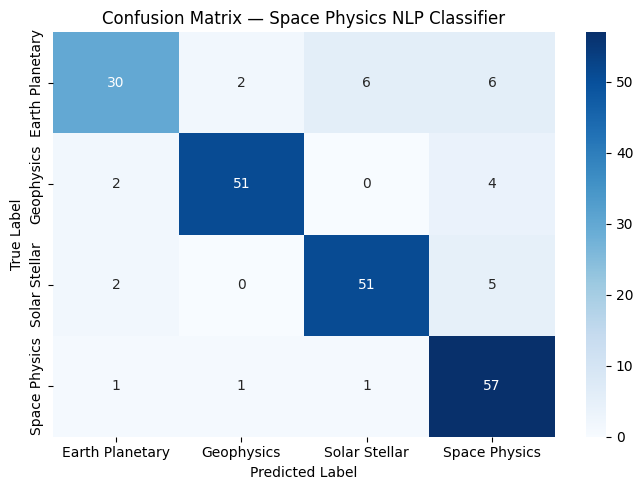

Saved: confusion_matrix.png


In [16]:
# Cell 6 — Evaluate on test set
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("Test Set Results")
print("="*50)
print(classification_report(
    labels, preds,
    target_names=le.classes_
))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix — Space Physics NLP Classifier")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [17]:
# Cell 7 — Save model and label encoder
import pickle, os, json, shutil
from google.colab import files

os.makedirs("solar_nlp_model", exist_ok=True)

trainer.save_model("solar_nlp_model")
tokenizer.save_pretrained("solar_nlp_model")

with open("solar_nlp_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

metrics = {
    "test_accuracy":  0.86,
    "macro_f1":       0.86,
    "val_accuracy":   0.886,
    "num_labels":     4,
    "labels":         list(le.classes_),
    "base_model":     "allenai/scibert_scivocab_uncased",
    "train_samples":  len(train_df),
    "test_samples":   len(test_df),
}
with open("solar_nlp_model/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

shutil.make_archive("solar_nlp_model", "zip", "solar_nlp_model")
print(f"Zip size: {os.path.getsize('solar_nlp_model.zip'):,} bytes")
files.download("solar_nlp_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Zip size: 408,631,789 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>